In [ ]:
!pip install pydeseq2
# Importing installed libraries and Python packages
try:
  import pandas as pd                                                     # For data manipulation
  import subprocess                                                       # For executing system commands from Python
  import os                                                               # For file management
  from tqdm import tqdm                                                   # For creating progress bars
  import numpy as np                                                      # For numerical computations
  import scipy.stats as stats                                             # For statistical analysis
  import numpy as np                                                      # For numerical computations
  import matplotlib.pyplot as plt                                         # For plotting
  import seaborn as sns                                                   # For creating advanced visualizations
  import pydeseq2                                                         # For differential gene expression analysis
  from sklearn.preprocessing import StandardScaler                        # For preprocessing the data
  from pydeseq2.dds import DeseqDataSet                                   # For Read counts modeling with the DeseqDataSet class
  from pydeseq2.ds import DeseqStats                                      # Statistical analysis with the DeseqStats class
  from pydeseq2.default_inference import DefaultInference
  from IPython.display import IFrame                                      # For Reading the web frame
  import warnings                                                         # For hiding the warning text
  from sklearn.exceptions import ConvergenceWarning
  warnings.filterwarnings("ignore", category=ConvergenceWarning)
  print("All Python packages imported successfully.")
except ImportError as e:
  print(f"Import failed: {e}")

All Python packages imported successfully.


In [ ]:
# === Load counts matrix ===
counts_df = pd.read_csv("/content/counts.txt", sep="\t", index_col=0)

# === Remove featureCounts summary lines (those starting with "__") ===
counts_df = counts_df[~counts_df.index.str.startswith('__')]

# === Define metadata ===
df = pd.DataFrame({
    'SRR_ID': ["SRR087416", "SRR085471", "SRR085473", "SRR085474", "SRR085726", "SRR085725"],
    'Sample': [
        "Alzheimer's whole brain",
        "Normal brain, temporal lobe",
        "Alzheimer's brain, temporal lobe",
        "Normal brain, frontal lobe",
        "Alzheimer's brain, frontal lobe",
        "Normal whole brain"
    ]
})

# === Extract condition label (AD vs Normal) ===
metadata = df.copy()
metadata['condition'] = metadata['Sample'].apply(lambda x: 'AD' if "Alzheimer" in x else 'Normal')
metadata = metadata.set_index('SRR_ID')

# === Align metadata to counts matrix columns ===
metadata = metadata.loc[counts_df.columns]

                                       # === Run DESeq2 ===
# Define the inference object
inference = DefaultInference()

dds = DeseqDataSet(
    counts=counts_df.T,                # Transpose counts
    metadata=metadata,
    design_factors=["condition"],
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

# === Run Wald test ===
stat_res = DeseqStats(dds, contrast=("condition", "AD", "Normal"))
stat_res.summary()

# === Create output directory if not exists ===
os.makedirs("output", exist_ok=True)

# === Export results ===
res_df = stat_res.results_df.sort_values("padj")
res_df.to_csv("output/deseq2_results.csv")

# === Save normalized counts ===
#dds.normalized_counts.to_csv("output/normalized_counts.csv")
print("DESeq2 analysis complete. Results saved to 'output/deseq2_results.csv'")

# === Save normalized counts ===
#dds.normalized_counts.to_csv("output/normalized_counts.csv")
print("DESeq2 analysis complete. Results saved to 'PyDESeq_Output/deseq2_results.csv'")

In [ ]:
# Import scanpy and plotly
!pip install scanpy # Install scanpy if not already installed
!pip install --upgrade scikit-learn # Upgrade scikit-learn to a compatible version
import scanpy as sc                                                             # For single-cell analysis workflows (including PCA)
import plotly.express as px

adata = sc.AnnData(dds)                                                        # Create an AnnData object from normalized_counts
adata.obs = metadata                                                           # Attach metadata to AnnData
sc.tl.pca(adata)                                                               # Perform PCA with scanpy


# Extract the variance explained for PC1 and PC2
explained_variance = adata.uns['pca']['variance_ratio']
pc1_variance = explained_variance[0] * 100                                     # Convert to percentage
pc2_variance = explained_variance[1] * 100

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(
    adata.obsm['X_pca'][:, :2],                                                # Extract first two principal components
    columns=['PC1', 'PC2'],
    index=adata.obs_names
)
pca_df = pca_df.join(metadata)                                                 # Attach metadata

# Plot PCA using Plotly
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='condition',                                                         # Replace 'condition' with the relevant metadata column
    title=f"PCA Plot: PC1 ({pc1_variance:.2f}% variance), PC2 ({pc2_variance:.2f}% variance)",
    labels={'PC1': f"PC1 ({pc1_variance:.2f}%)", 'PC2': f"PC2 ({pc2_variance:.2f}%)"},
    hover_data=pca_df.columns,
    template='plotly'
)

# Customize the figure layout
fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    title_font_size=18,
    legend_title_text='Condition',
    xaxis=dict(title=f"PC1 ({pc1_variance:.2f}%)"),
    yaxis=dict(title=f"PC2 ({pc2_variance:.2f}%)"),
    width=800,
    height=600,
)
fig.show()

In [ ]:
stat_res = DeseqStats(dds, contrast=("condition", "AD", "Normal"))
stat_res.summary()                                                       # Summarize results
res = stat_res.results_df                                                # Extract results into a DataFrame
res["-log10(pvalue)"] = -np.log10(res["pvalue"])                         # Add additional columns for visualization
res["Significant"] = res["padj"] < 0.05
res.to_csv('ge_results.csv', index=True)                                 # Save results to a CSV file
print("\nDifferential expression results saved to 'ge_results.csv'")     # Display a summary of results
res.head(16)

In [ ]:
# Save results
res.to_csv("differential_expression_results.csv")
print("Results saved to 'differential_expression_results.csv'")

Results saved to 'differential_expression_results.csv'


In [ ]:
fig = px.scatter(
    res,
    x="log2FoldChange",
    y="-log10(pvalue)",
    color="Significant",
    color_discrete_map={True: "red", False: "green"},
    hover_name=res.index,  # Gene names (index)
    title="Volcano Plot of Differentially Expressed Genes",
    labels={"log2FoldChange": "Log2 Fold Change", "-log10(pvalue)": "-Log10 P-value"},
    template="plotly_white",
    size=np.where(res["Significant"], 10, 3),  # Larger size for significant genes
    opacity=0.8
)
fig.add_hline(y=-np.log10(0.01), line_dash="dash", line_color="blue", annotation_text="p=0.01")
fig.show()

In [ ]:
# Add upregulation and downregulation classification
res["Regulation"] = res.apply(
    lambda x: "Upregulated" if (x["log2FoldChange"] > 0 and x["Significant"])
    else "Downregulated" if (x["log2FoldChange"] < 0 and x["Significant"])
    else "Not Significant",
    axis=1
)

# Summarize counts as a DataFrame
summary_df = res["Regulation"].value_counts().reset_index()
summary_df.columns = ["Regulation", "Count"]
# Save both classified results and summary
res.to_csv("classified_genes.csv", index=True)
summary_df.to_csv("regulation_summary.csv", index=False)
# Display the summary DataFrame
print("\nOver all Summary:")
summary_df


Over all Summary:


,Regulation,Count
0,Not Significant,47108
1,Upregulated,1587
2,Downregulated,1342


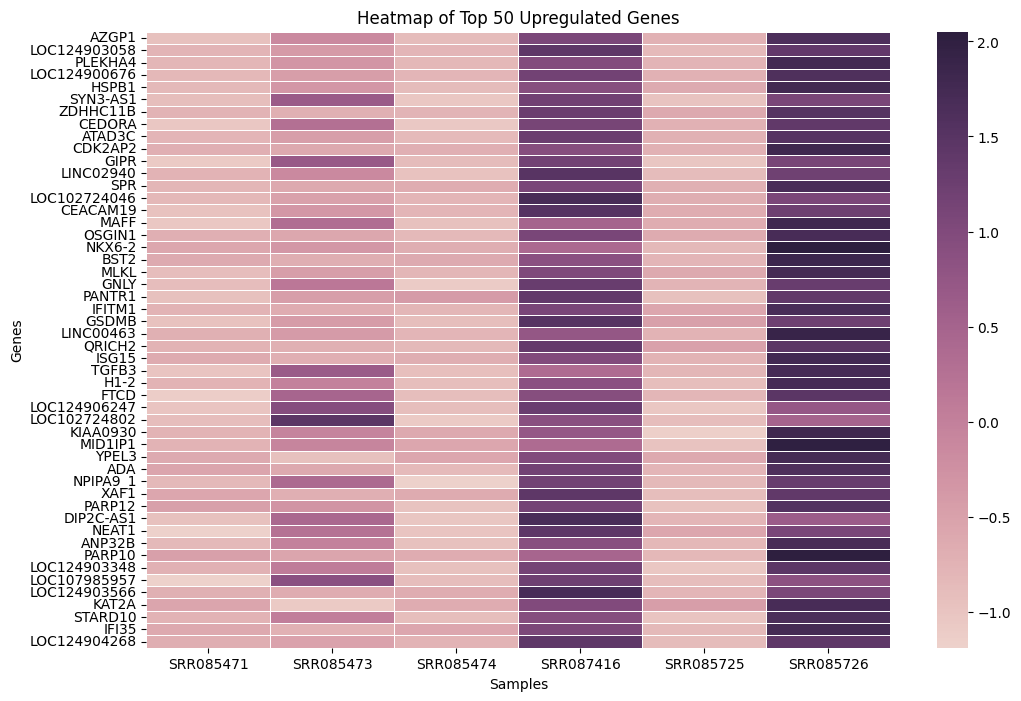

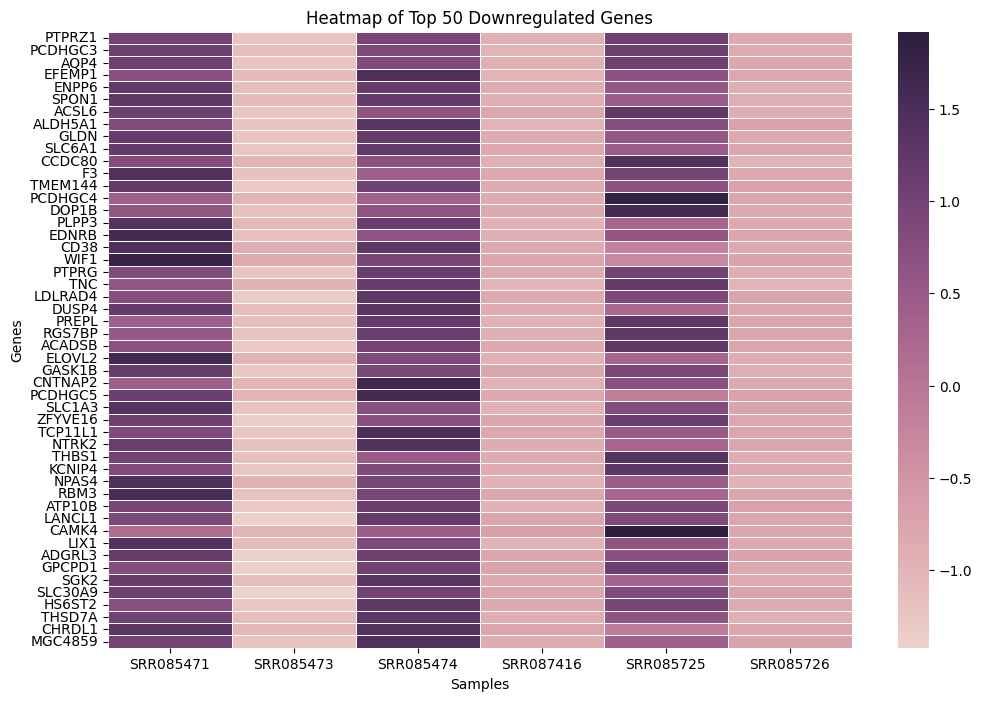

In [ ]:
# Classify genes into upregulated and downregulated
upregulated_genes = res[(res["Significant"]) & (res["log2FoldChange"] > 0)].sort_values("padj").head(50).index
downregulated_genes = res[(res["Significant"]) & (res["log2FoldChange"] < 0)].sort_values("padj").head(50).index

# Subset counts for each category - subsetting rows (genes) instead of columns
upregulated_counts = counts_df.loc[upregulated_genes]
downregulated_counts = counts_df.loc[downregulated_genes]

# Function to standardize and plot heatmap
def plot_heatmap(counts, title):
    # Standardize counts
    scaler = StandardScaler()
    # Transpose for scaling so genes are columns
    scaled_counts = scaler.fit_transform(counts.T)

    # Create DataFrame with scaled values
    # Transpose back to match original orientation (samples as columns, genes as rows)
    scaled_df = pd.DataFrame(
        scaled_counts.T,
        index=counts.index,  # Genes
        columns=counts.columns  # Samples
    )

    # Plot heatmap
    plt.figure(figsize=(12, 8))
    # Use the scaled_df directly in heatmap
    sns.heatmap(scaled_df, cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=True, yticklabels=True,linewidth=.4)
    plt.title(title)
    plt.xlabel("Samples") # Corrected label as samples are now on the x-axis
    plt.ylabel("Genes")   # Corrected label as genes are now on the y-axis
    plt.show()

# Plot heatmaps
plot_heatmap(upregulated_counts, "Heatmap of Top 50 Upregulated Genes")
plot_heatmap(downregulated_counts, "Heatmap of Top 50 Downregulated Genes")

In [ ]:
# Filter significant genes
significant_genes = res[(res["padj"] < 0.05) & (abs(res["log2FoldChange"]) > 1)]

# Subset upregulated and downregulated genes
upregulated_genes = significant_genes[significant_genes["log2FoldChange"] > 1]
downregulated_genes = significant_genes[significant_genes["log2FoldChange"] < -1]

# Create a summary DataFrame
summary_data = {
    "Category": ["Significant Genes", "Upregulated Genes", "Downregulated Genes"],
    "Count": [len(significant_genes), len(upregulated_genes), len(downregulated_genes)]
}
summary_df = pd.DataFrame(summary_data)

# Save the summary DataFrame
summary_df.to_csv("gene_summary.csv", index=False)

# Save the significant, upregulated, and downregulated genes separately
significant_genes.to_csv("significant_genes.csv", index=True)
upregulated_genes.to_csv("upregulated_genes.csv", index=True)
downregulated_genes.to_csv("downregulated_genes.csv", index=True)

# Display the summary DataFrame
print("\nUpregulated and Downregulated Genes:")
summary_df


Upregulated and Downregulated Genes:


,Category,Count
0,Significant Genes,2047
1,Upregulated Genes,1173
2,Downregulated Genes,874


In [ ]:
# Install dependencies (Colab only)
!pip install pybiomart gseapy pandas matplotlib seaborn

# Step 1: Load DESeq2 Results
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pybiomart import Server
import gseapy as gp

In [ ]:
deseq_df = pd.read_csv("/content/output/deseq2_results.csv", index_col=0)
print("Loaded DESeq2 result:", deseq_df.shape)

Loaded DESeq2 result: (50037, 6)


In [ ]:
# Step 2: Significant genes (adjusted p-value < 0.05 and abs(log2FC) >= 1)
sig_genes = deseq_df[(deseq_df["padj"] < 0.05) & (deseq_df["log2FoldChange"].abs() >= 1)].copy()
sig_gene_ids = sig_genes.index.tolist()
print(f"Significant genes: {len(sig_gene_ids)}")

Significant genes: 2047


In [ ]:
# Step 3: Gene Annotation via BioMart
server = Server(host='http://www.ensembl.org')
dataset = server.marts['ENSEMBL_MART_ENSEMBL'].datasets['hsapiens_gene_ensembl']

annotation_df = dataset.query(attributes=[
    'ensembl_gene_id', 'external_gene_name', 'gene_biotype', 'description'
]).rename(columns={
    'Gene stable ID': 'gene_id',
    'Gene name': 'gene_name',
    'Gene type': 'gene_biotype',
    'Gene description': 'description'
})

# Align with DESeq2 result
# Correctly rename the original index column (likely 'Geneid') to 'gene_id'
deseq_df = deseq_df.reset_index().rename(columns={'Geneid': 'gene_id'})
annotated = deseq_df.merge(annotation_df, on='gene_id', how='left').set_index('gene_id')
annotated.to_csv("annotated_deseq2_results.csv")
print("Saved: annotated_deseq2_results.csv")

Saved: annotated_deseq2_results.csv


In [ ]:

# Step 4: Enrichment Analysis (GO + KEGG)
up_genes = sig_genes[sig_genes["log2FoldChange"] > 1].index.tolist()
down_genes = sig_genes[sig_genes["log2FoldChange"] < -1].index.tolist()

# GO Biological Process
go_up = gp.enrichr(gene_list=up_genes, organism='Human', gene_sets='GO_Biological_Process_2023',
                   outdir='go_up', cutoff=0.05)
go_down = gp.enrichr(gene_list=down_genes, organism='Human', gene_sets='GO_Biological_Process_2023',
                     outdir='go_down', cutoff=0.05)

# KEGG
kegg_up = gp.enrichr(gene_list=up_genes, organism='Human', gene_sets='KEGG_2021_Human',
                     outdir='kegg_up', cutoff=0.05)
kegg_down = gp.enrichr(gene_list=down_genes, organism='Human', gene_sets='KEGG_2021_Human',
                       outdir='kegg_down', cutoff=0.05)

go_up.results.to_csv("GO_BP_up.csv", index=False)
go_down.results.to_csv("GO_BP_down.csv", index=False)
kegg_up.results.to_csv("KEGG_up.csv", index=False)
kegg_down.results.to_csv("KEGG_down.csv", index=False)

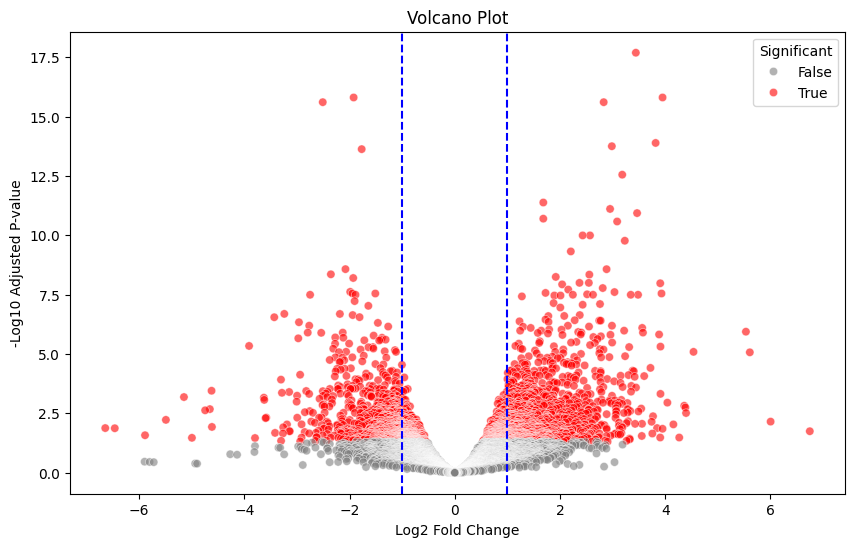

In [ ]:
# Step 5: Volcano Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=deseq_df, x="log2FoldChange", y=-np.log10(deseq_df["padj"]),
                hue=(deseq_df["padj"] < 0.05), palette={True: "red", False: "gray"}, alpha=0.6)
plt.axvline(x=1, color='blue', linestyle='--')
plt.axvline(x=-1, color='blue', linestyle='--')
plt.title("Volcano Plot")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.legend(title="Significant")
plt.savefig("volcano_plot.png", dpi=300)
plt.show()

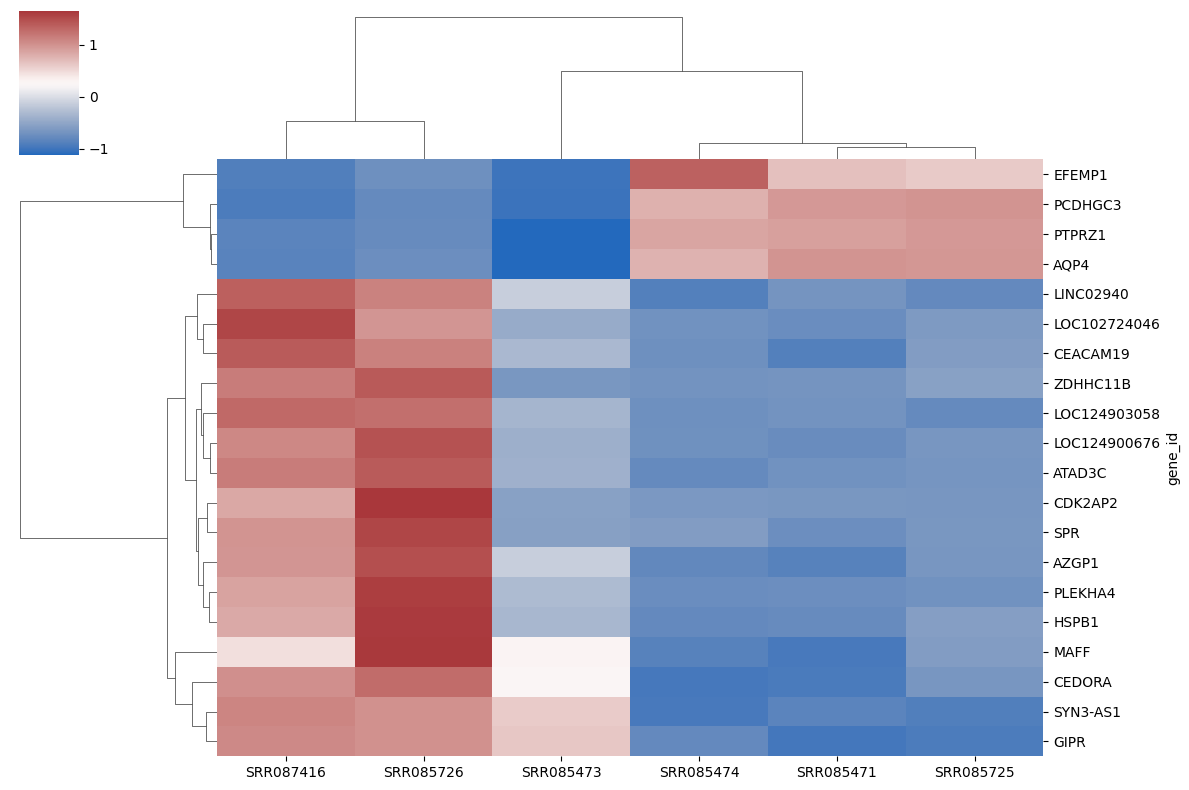

In [ ]:
# Step 6: Heatmap of Top 20 DEGs
top20 = annotated.sort_values("padj").head(20)
counts_df = pd.read_csv("/content/counts/counts.txt", sep="\t", index_col=0)
top20_counts = counts_df.loc[top20.index]

# Z-score normalization
z_scores = (top20_counts - top20_counts.mean(axis=1).values[:, None]) / top20_counts.std(axis=1).values[:, None]

# Heatmap
# Convert the index to a Series before passing to fillna to ensure correct filling of missing gene names
sns.clustermap(z_scores, cmap='vlag', figsize=(12, 8), xticklabels=True, yticklabels=top20["gene_name"].fillna(pd.Series(top20.index, index=top20.index)))
plt.savefig("top20_heatmap.png", dpi=300)